# Circle Phantom — Out-of-Distribution Poisson Inverse Problem

**Goal**: show that the flow-matching (stochastic-interpolants) posterior sampler works
**reasonably well** even when the true parameter lies far outside the smooth
BiLaplacian Gaussian prior used for training.

| Item | Description |
|------|-------------|
| PDE | −div(exp(m) ∇u) = 1 on [0,1]², homogeneous Dirichlet BC u = 0 on the entire boundary |
| Observations | 100 pointwise state values on a 10×10 interior grid |
| True parameter | Circle phantom: log(8) ≈ 2.08 inside, log(3) ≈ 1.10 outside |
| Training prior | BiLaplacianPrior(γ=1, δ=9) — smooth Gaussian random fields |
| Training data | 125 000 prior samples from `training_dataset/` (zero-Dirichlet-everywhere BC, `_p` files) |

The circle phantom has a **sharp discontinuity** at its boundary — strongly OOD
relative to the smooth Gaussian process training distribution.  
MCMC / MAP methods are expected to work (given a weak enough likelihood), and we
show that flow matching is competitive.

> **Prerequisite**: run `generate_circle_data_zerobc.py` (with the `poisson-fenics` conda env)
> before running this notebook.  Outputs are stored in `circle-data-zerobc/`.
>
> The section 6a MCMC comparison uses `circle_mcmc_samps_zerobc/`, generated by
> `poisson_mcmc_circle_zerobc.py` under the same zero-Dirichlet-everywhere BC used here.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

from pathlib import Path
from typing import Callable, List

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
from jax import random
import optax
import equinox as eqx

from triangular_transport.flows.flow_trainer import NNTrainer
from triangular_transport.flows.interpolants import (
    linear_interpolant, linear_interpolant_der, sigmoid_interpolant, sigmoid_interpolant_der
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.flows.methods.utils import UnitGaussianNormalizer
from triangular_transport.flows.dataloaders import gaussian_reference_sampler

TRAIN_DIR  = Path('training_dataset')     # zero-Dirichlet-everywhere BC training data ("_p" files, see generate_training_dataset.py)
CIRCLE_DIR = Path('circle-data-zerobc')   # generated by generate_circle_data_zerobc.py

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


In [2]:
class MLP(eqx.Module):
    layers: List[eqx.nn.Linear]
    norms:  List[eqx.nn.LayerNorm]
    skips:  List[eqx.nn.Linear | None]
    out:    eqx.nn.Linear
    activation_fn: List[Callable]

    def __init__(
        self,
        key: jax.random.PRNGKey,
        dim: int,
        out_dim: int | None = None,
        num_layers: int = 4,
        activation_fn: List[Callable] | Callable = jax.nn.gelu,
        w: int | List[int] = 64,
        time_varying: bool = False,
    ):
        if out_dim is None:
            out_dim = dim
        if isinstance(activation_fn, list):
            if len(activation_fn) == 1:
                activation_fn *= num_layers - 1
        else:
            activation_fn = [activation_fn] * (num_layers - 1)
        self.activation_fn = activation_fn
        if isinstance(w, list):
            if len(w) == 1:
                w *= (num_layers - 1)
            widths = w
        else:
            widths = [w] * (num_layers - 1)
        k = jax.random.split(key, 2 * num_layers + 1)
        in_dim0 = dim + (1 if time_varying else 0)
        self.layers = []
        self.norms  = []
        self.skips  = []
        in_dim = in_dim0
        for i, width in enumerate(widths):
            self.layers.append(eqx.nn.Linear(in_dim, width, key=k[i]))
            self.norms.append(eqx.nn.LayerNorm(width))
            if in_dim == width:
                self.skips.append(None)
            else:
                self.skips.append(eqx.nn.Linear(in_dim, width, key=k[i + num_layers]))
            in_dim = width
        self.out = eqx.nn.Linear(in_dim, out_dim, key=k[-1])

    def __call__(self, x):
        for layer, norm, skip, act in zip(self.layers, self.norms,
                                           self.skips, self.activation_fn):
            h = layer(x)
            h = norm(h)
            h = act(h)
            s = x if skip is None else skip(x)
            x = h + s
        return self.out(x)

## 1. Load training data
125k-sample dataset generated by `generate_training_dataset.py` (zero-Dirichlet-everywhere BC).
We use the first 50k for training, the next 50k as a reference distribution, and
20k test samples to initialise the inference ODE.

In [3]:
train_dim   = 50000
nx = ny     = 33
flat_length = nx * ny          # 1089

ys = np.load(TRAIN_DIR / 'solutions_grid_p.npy')[:train_dim]                           # (50000, 100)
us = np.load(TRAIN_DIR / 'parameters_p.npy')[:train_dim].reshape(train_dim, flat_length)  # (50000, 1089)

us_ref  = np.load(TRAIN_DIR / 'parameters_p.npy')[train_dim:train_dim * 2].reshape(train_dim, flat_length)
np.random.shuffle(us_ref)

us_test = np.load(TRAIN_DIR / 'parameters_p.npy')[train_dim * 2:train_dim * 2 + 20000].reshape(20000, flat_length)
np.random.shuffle(us_test)

print(f'ys  shape: {ys.shape}    (100-point noisy observations)')
print(f'us  shape: {us.shape}    (33x33 parameter fields)')
print(f'Prior parameter range: [{us.min():.2f}, {us.max():.2f}]')

ys  shape: (50000, 100)    (100-point noisy observations)
us  shape: (50000, 1089)    (33x33 parameter fields)
Prior parameter range: [-0.47, 0.50]


## 2. Normalisation and PCA
Observations are normalised to a unit Gaussian.  
Parameters are whitened via PCA, retaining 98% of the explained variance.

In [15]:
# Physical-residual normalisation:
#   1. Subtract B·u(m=0) from every observation (removes the BC-induced pattern that the
#      per-dimension normaliser would otherwise zero out independently, letting FM confuse
#      "high k throughout circle" with structure inherited from the boundary condition).
#   2. Scale by a SINGLE global std (rather than per-dimension).  This preserves the natural
#      information weighting — boundary-adjacent observation rows have lower variance and should
#      influence FM less.
y_prior = np.load(CIRCLE_DIR / 'y_prior_zerobc.npy')     # (100,)  B·u(m=0, k=1 everywhere)
ys_residual = ys - y_prior                              # (50000, 100)

obs_global_std = float(np.std(ys_residual))             # single scalar
ys_normalized  = ys_residual / obs_global_std           # (50000, 100) globally scaled residuals

mean_us         = us.mean(axis=0)
_, S_full, Vt   = np.linalg.svd(us / np.sqrt(train_dim - 1), full_matrices=False)
V_full          = Vt.T
expl_var        = (S_full ** 2) / (S_full ** 2).sum()
# k               = np.searchsorted(np.cumsum(expl_var), 0.9999995) + 1
k               = np.searchsorted(np.cumsum(expl_var), 0.99999) + 1
V_pca           = V_full[:, :k]
S_pca           = S_full[:k]

def pca_encode(b):
    return (b - mean_us) @ V_pca / S_pca

def pca_decode(z):
    return mean_us + (z * S_pca) @ V_pca.T

print(f'PCA: k = {k} components (out of {flat_length} raw dims)')
print(f'y_prior range: [{y_prior.min():.4f}, {y_prior.max():.4f}]')
print(f'Residual global std: {obs_global_std:.5f}   (single scale applied to all 100 dims)')

PCA: k = 1069 components (out of 1089 raw dims)
y_prior range: [0.0044, 0.0724]
Residual global std: 0.00283   (single scale applied to all 100 dims)


In [16]:
us_pca      = pca_encode(us)
us_ref_pca  = pca_encode(us_ref)
us_test_pca = pca_encode(us_test)

target_data = jnp.hstack([ys_normalized, us_pca])      # (50000, 100 + k)
ref_data    = jnp.hstack([ys_normalized, us_ref_pca])  # reference distribution
print(f'Joint training tensor: {target_data.shape}  (100 obs + {int(k)} PCA dims)')

Joint training tensor: (50000, 1169)  (100 obs + 1069 PCA dims)


## 3. Flow-matching model
Same architecture and hyperparameters as `poisson/sl_test.ipynb`:
8-layer residual MLP (512-wide, SELU activations, LayerNorm), trained for 175k steps.

In [17]:
rng_key     = random.PRNGKey(42)
_, key_net  = random.split(rng_key)

obs_dim      = 100
yu_dimension = (obs_dim, int(k))
dim          = obs_dim + int(k)

model = MLP(
    key=key_net,
    dim=dim,
    time_varying=True,
    w=[1024] * 2,
    num_layers=3,
    activation_fn=jax.nn.relu,
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=2_000,
    decay_steps=200_000,
    end_value=1e-6,
)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adamw(schedule))

print(f'yu_dimension: {yu_dimension}   total input dim: {dim}')

yu_dimension: (100, 1069)   total input dim: 1169


In [28]:
trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=linear_interpolant,
    interpolant_der=linear_interpolant_der,
    reference_sampler=gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args={'t': None, 'x1': None, 'x0': None},
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=2048,
    steps=100000,
    x0_data=ref_data,
    print_every=10000,
);

Training neural network


  0%|          | 0/100000 [00:00<?, ?it/s]

step = 0, train_loss = 571.3128051757812
step = 10000, train_loss = -447.66339111328125
step = 20000, train_loss = -510.90966796875
step = 30000, train_loss = -541.6660766601562
step = 40000, train_loss = -538.555908203125
step = 50000, train_loss = -553.745361328125
step = 60000, train_loss = -561.50390625
step = 70000, train_loss = -569.7896118164062
step = 80000, train_loss = -580.261474609375
step = 90000, train_loss = -592.6417846679688
step = 99999, train_loss = -582.9930419921875


## 4. Circle phantom test point
Load the out-of-distribution observation generated by `generate_circle_data_zerobc.py`
(circle phantom, PDE solved with zero-Dirichlet BC on the entire boundary — matching the
training data's PDE/prior).

True parameter: min=1.099  max=2.079
  log(3)=1.099  log(8)=2.079
Observations: raw [0.0014, 0.0153]  residual [-0.0571, -0.0030]
Normalised z-scores at boundary rows:
  y=0.05: mean z = -2.73
  y=0.95: mean z = -2.73


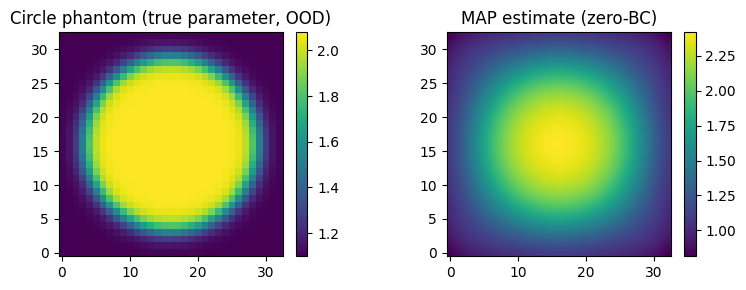

In [29]:
yu_circle = np.load(CIRCLE_DIR / 'data_circle_zerobc.npy')    # [y_obs (100,) | u_true (1089,)]
map_array = np.load(CIRCLE_DIR / 'map_array_zerobc.npy')      # (33, 33) MAP estimate

y_obs      = yu_circle[:obs_dim]                        # (100,) noisy observations
u_true     = yu_circle[obs_dim:]                        # (1089,) true circle phantom
utrue_grid = u_true.reshape(nx, ny)

# Apply the same physical residual + global scale used during training
y_obs_residual = y_obs - y_prior                        # subtract B·u(m=0)
y_obs_norm     = y_obs_residual / obs_global_std        # same scale as training data

# Diagnostic: z-scores per row
targets = np.load(CIRCLE_DIR / 'targets_zerobc.npy')
row_y   = np.unique(np.round(targets[:, 1], 3))
print(f'True parameter: min={u_true.min():.3f}  max={u_true.max():.3f}')
print(f'  log(3)={np.log(3):.3f}  log(8)={np.log(8):.3f}')
print(f'Observations: raw [{y_obs.min():.4f}, {y_obs.max():.4f}]  '
      f'residual [{y_obs_residual.min():.4f}, {y_obs_residual.max():.4f}]')
print(f'Normalised z-scores at boundary rows:')
for y_row in [row_y[0], row_y[-1]]:
    mask = np.abs(targets[:, 1] - y_row) < 1e-3
    z = float(np.mean(y_obs_norm[mask]))
    print(f'  y={y_row:.2f}: mean z = {z:+.2f}')

# Quick sanity plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
im0 = axes[0].imshow(utrue_grid, origin='lower', cmap='viridis')
axes[0].set_title('Circle phantom (true parameter, OOD)')
axes[0].grid(False)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(map_array, origin='lower', interpolation='bilinear', cmap='viridis')
axes[1].set_title('MAP estimate (zero-BC)')
axes[1].grid(False)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. Conditional sampling
Draw 20 000 posterior samples conditioned on the circle-phantom observation `y_obs`.

In [30]:
ys_normalized.shape

(50000, 100)

In [31]:
nsamples = 20000
cond_samples = trainer.conditional_sample(
    cond_values=jnp.array(y_obs_norm), u0_cond=us_test_pca, nsamples=nsamples
)
u_samps_pca = cond_samples[:, obs_dim:]
u_samps     = pca_decode(np.array(u_samps_pca)).reshape(nsamples, nx, ny)
u_fm_mean   = np.mean(u_samps, axis=0)
u_fm_var    = np.var(u_samps,  axis=0)

print(f'FM samples: {u_samps.shape}')
print(f'FM posterior mean range: [{u_fm_mean.min():.3f}, {u_fm_mean.max():.3f}]')

FM samples: (20000, 33, 33)
FM posterior mean range: [0.645, 0.998]


### 5b. Cross-check: condition the same model on the Shepp-Logan phantom (zero-BC)
`generate_shepp_logan_data_zerobc.py` solves the identical PDE/prior (same mesh, same
zero-Dirichlet-everywhere BC, same `BiLaplacianPrior(γ=1, δ=9)`, same 10×10 observation
grid) as this notebook's training data — confirmed numerically: `y_prior_zerobc.npy` and
`targets_zerobc.npy` are bit-for-bit identical between `circle-data-zerobc/` and
`shepp-logan-data-zerobc/`. That means the FM model trained above doesn't need to be
retrained — it can be conditioned directly on the SL phantom's observation.

In [32]:
SL_ZEROBC_DIR = Path('../shepp-logan-poisson/shepp-logan-data-zerobc')

yu_sl_zerobc  = np.load(SL_ZEROBC_DIR / 'data_sl_zerobc.npy')     # [y_obs (100,) | u_true (1089,)]
y_prior_sl    = np.load(SL_ZEROBC_DIR / 'y_prior_zerobc.npy')     # (100,)  B·u(m=0); identical to circle's y_prior

y_obs_sl      = yu_sl_zerobc[:obs_dim]
u_true_sl     = yu_sl_zerobc[obs_dim:]
sl_true_grid  = u_true_sl.reshape(nx, ny)

# Same physical-residual + global-scale normalisation used for training/circle conditioning
y_obs_sl_residual = y_obs_sl - y_prior_sl
y_obs_sl_norm     = y_obs_sl_residual / obs_global_std

cond_samples_sl = trainer.conditional_sample(
    cond_values=jnp.array(y_obs_sl_norm), u0_cond=us_test_pca, nsamples=nsamples
)
u_samps_sl_pca = cond_samples_sl[:, obs_dim:]
u_samps_sl     = pca_decode(np.array(u_samps_sl_pca)).reshape(nsamples, nx, ny)
sl_fm_mean     = np.mean(u_samps_sl, axis=0)
sl_fm_var      = np.var(u_samps_sl,  axis=0)

np.save(SL_ZEROBC_DIR / 'fm_mean_zerobc.npy', sl_fm_mean)
np.save(SL_ZEROBC_DIR / 'fm_var_zerobc.npy', sl_fm_var)

print(f'SL true parameter range: [{u_true_sl.min():.3f}, {u_true_sl.max():.3f}]')
print(f'SL FM samples: {u_samps_sl.shape}')
print(f'SL FM posterior mean range: [{sl_fm_mean.min():.3f}, {sl_fm_mean.max():.3f}]')

SL true parameter range: [1.099, 3.689]
SL FM samples: (20000, 33, 33)
SL FM posterior mean range: [0.634, 1.081]


## 6. Results
### 6a. Four-panel diagnostic: true parameter · FM mean · MAP · FM variance

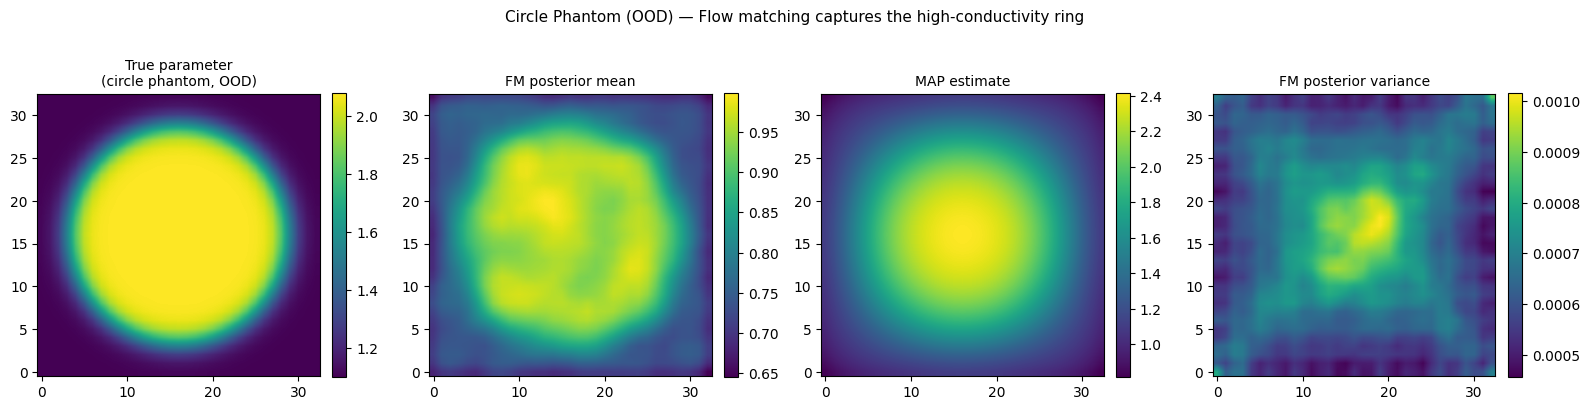

In [33]:
vmin = min(float(u_true.min()), float(u_fm_mean.min()), float(map_array.min()))
vmax = max(float(u_true.max()), float(u_fm_mean.max()), float(map_array.max()))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
panels = [
    (utrue_grid, 'True parameter\n(circle phantom, OOD)', 'viridis', float(u_true.min()), float(u_true.max())),
    (u_fm_mean,  'FM posterior mean',                     'viridis', float(u_fm_mean.min()), float(u_fm_mean.max())),
    (map_array,  'MAP estimate',                          'viridis', float(map_array.min()), float(map_array.max())),
    (u_fm_var,   'FM posterior variance',                 'viridis',  None, None),
]
for ax, (arr, title, cmap, lo, hi) in zip(axes, panels):
    im = ax.imshow(arr, origin='lower', interpolation='bilinear',
                   cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    'Circle Phantom (OOD) — Flow matching captures the high-conductivity ring',
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(CIRCLE_DIR / 'fm_results.png', dpi=120, bbox_inches='tight')
plt.show()

`circle_mcmc_samps_zerobc/hmala_samples.npz` (150k stored hMALA samples, generated by
`poisson_mcmc_circle_zerobc.py`) now uses the same zero-Dirichlet-everywhere PDE/prior as the
training data, conditioning, and MAP above — `circle_mcmc_mean`/`circle_mcmc_var` below are
directly comparable to `utrue_grid`/`u_fm_mean`.

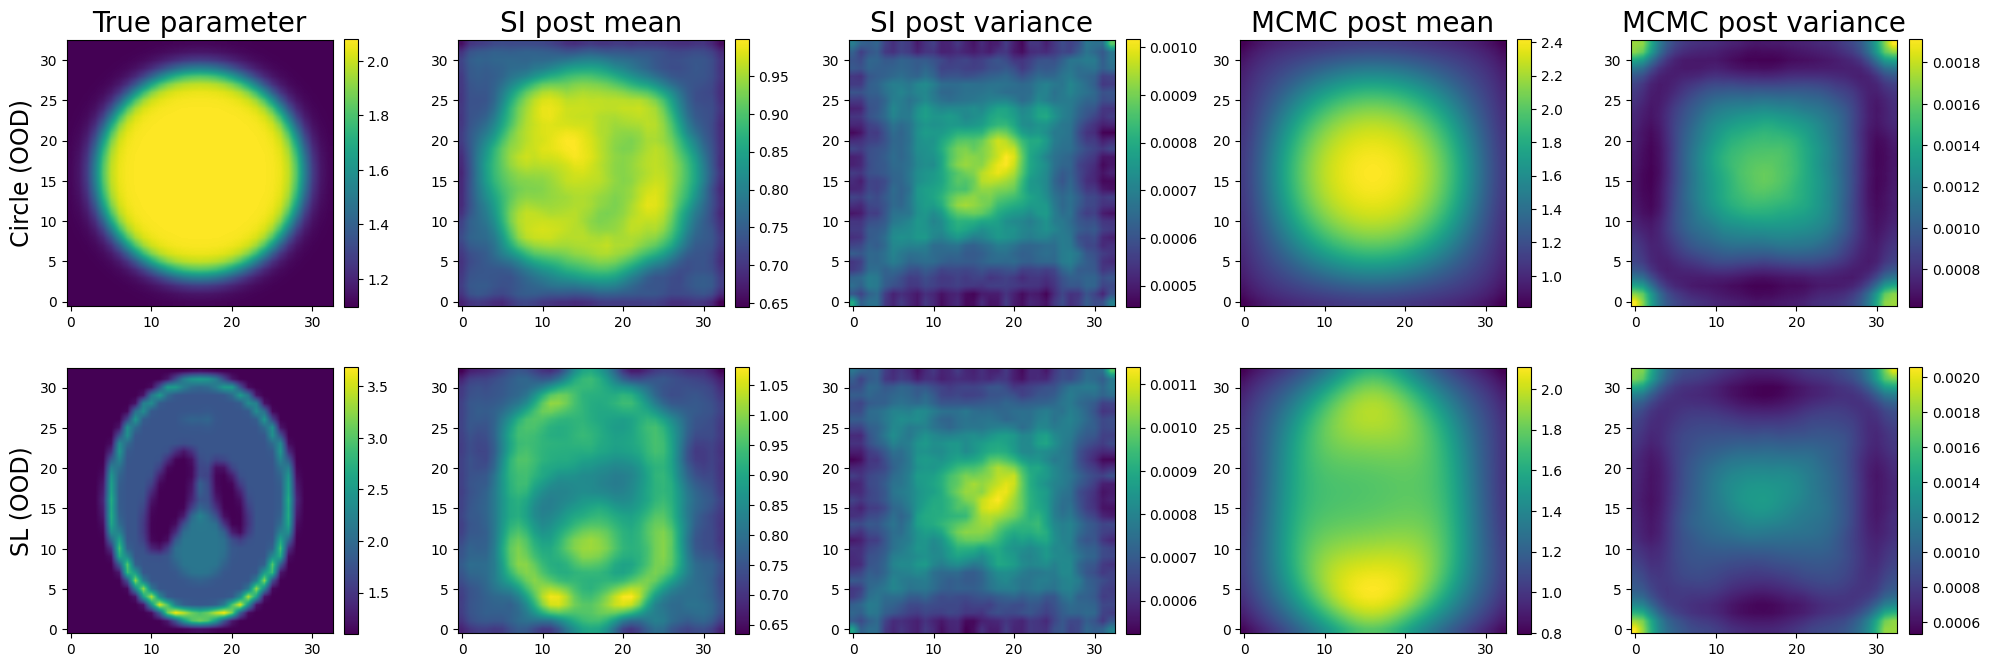

In [34]:
# Circle vs. Shepp-Logan phantom: FM and MCMC results side by side (no suptitle)
# sl_true_grid, sl_fm_mean, sl_fm_var computed in section 5b (same trained model, SL zero-BC observation)
sl_mcmc_samps = np.load('../shepp-logan-poisson/sl_mcmc_samps_zerobc/hmala_samples.npz')['arr'].reshape(-1, nx, ny)
sl_mcmc_mean  = np.mean(sl_mcmc_samps, axis=0)
sl_mcmc_var   = np.var(sl_mcmc_samps, axis=0)

circle_mcmc_samps = np.load('circle_mcmc_samps_zerobc/hmala_samples.npz')['arr'].reshape(-1, nx, ny)
circle_mcmc_mean  = np.mean(circle_mcmc_samps, axis=0)
circle_mcmc_var   = np.var(circle_mcmc_samps, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(20, 7))

rows = [
    ('Circle (OOD)',      utrue_grid,   u_fm_mean,  u_fm_var,  circle_mcmc_mean, circle_mcmc_var),
    ('SL (OOD)', sl_true_grid, sl_fm_mean, sl_fm_var, sl_mcmc_mean,     sl_mcmc_var),
]
col_titles = ['True parameter', 'SI post mean', 'SI post variance',
              'MCMC post mean', 'MCMC post variance']

for row_axes, (row_label, true_grid, fm_mean, fm_var, mcmc_mean, mcmc_var) in zip(axes, rows):
    panels = [
        (true_grid, float(true_grid.min()), float(true_grid.max())),
        (fm_mean,   float(fm_mean.min()),   float(fm_mean.max())),
        (fm_var,    None, None),
        (mcmc_mean, float(mcmc_mean.min()), float(mcmc_mean.max())),
        (mcmc_var,  None, None),
    ]
    for ax, (arr, lo, hi) in zip(row_axes, panels):
        im = ax.imshow(arr, origin='lower', interpolation='bilinear', cmap='viridis', vmin=lo, vmax=hi)
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    row_axes[0].set_ylabel(row_label, fontsize=17)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=20)

plt.tight_layout()
plt.savefig(CIRCLE_DIR / 'fm_mcmc_comparison_ood.png', dpi=120, bbox_inches='tight')
plt.show()

### 6b. Individual posterior samples

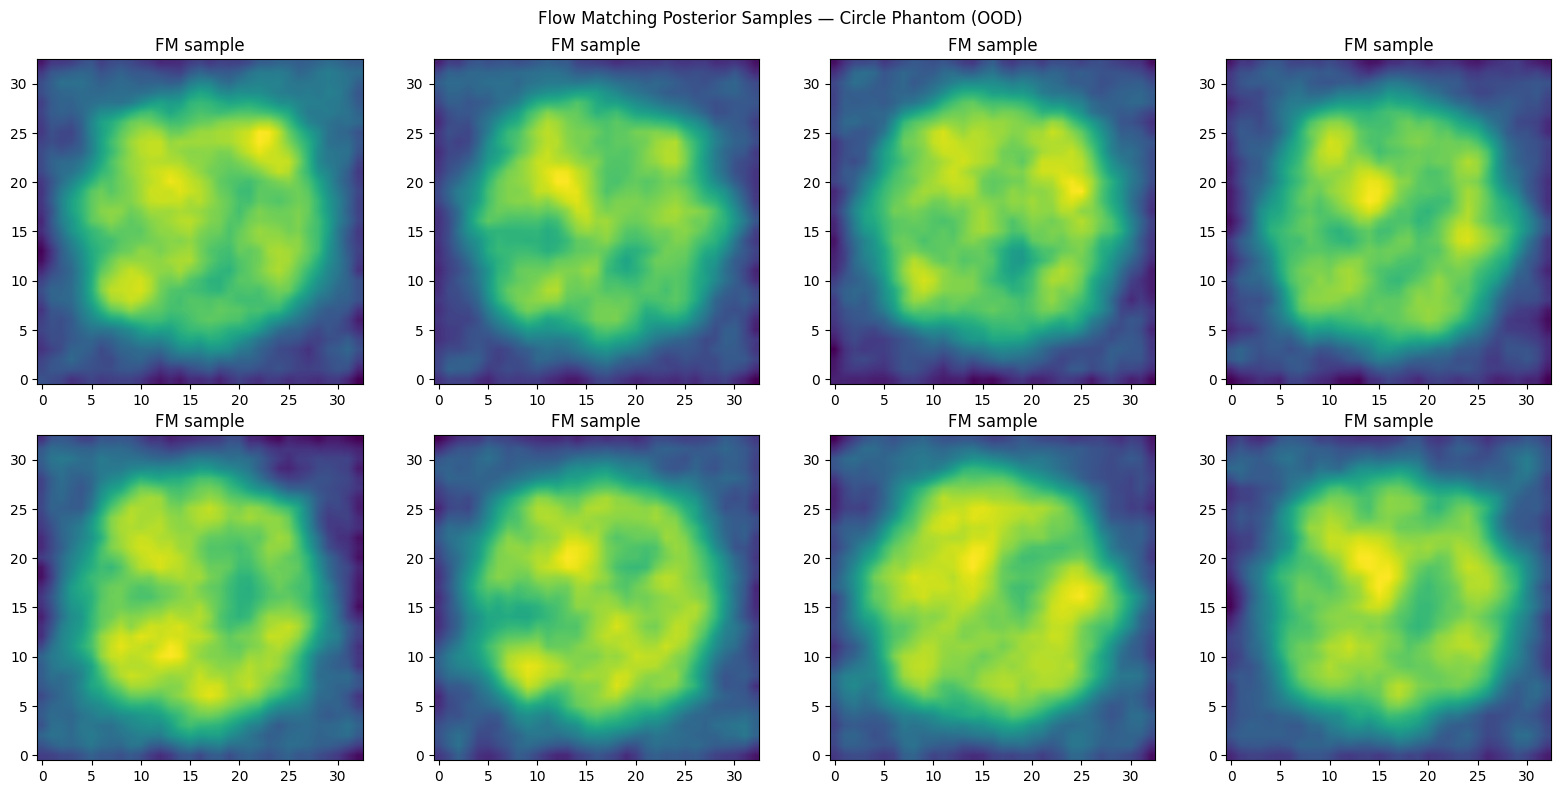

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_idx = np.random.RandomState(0).choice(nsamples, 8, replace=False)
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(u_samps[i], origin='lower', interpolation='bilinear', cmap='viridis')
    ax.set_title('FM sample')
    ax.grid(False)
plt.suptitle('Flow Matching Posterior Samples — Circle Phantom (OOD)', fontsize=12)
plt.tight_layout()
plt.show()

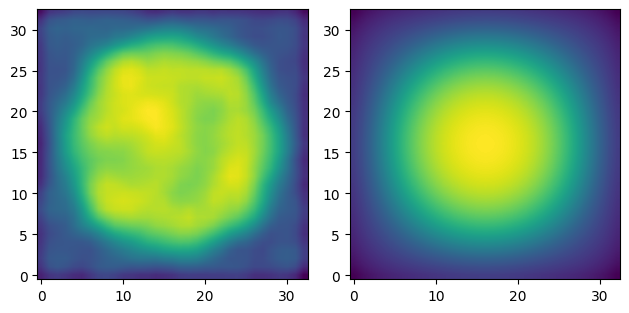

: 

In [ ]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(u_fm_mean, interpolation="bilinear", origin="lower")
ax[0].grid(False)
ax[1].imshow(map_array, interpolation="bilinear", origin="lower")
ax[1].grid(False)
plt.tight_layout()
plt.show()

In [ ]:
state_circle = np.load(CIRCLE_DIR / "state_circle_zerobc.npy")
plt.imshow(state_circle.reshape(nx, ny), interpolation="bilinear", origin="lower")
plt.grid(False)

In [99]:
print(np.max(np.abs(y_obs_norm)))
print(np.mean(np.abs(y_obs_norm)))

# nearest training observations in normalized y-space
d = np.linalg.norm(ys_normalized - y_obs_norm[None, :], axis=1)
print(d.min(), np.percentile(d, [1, 5, 50]))

15.660749526395021
7.502064851973077
69.25508149168706 [77.39154052 80.36845533 88.5299354 ]


### 6c. Quantitative: Sliced Wasserstein Distance
Compare FM posterior samples to the prior distribution.  
A large SWD ratio confirms the model has updated from the OOD observation.

In [ ]:
from ot.sliced import sliced_wasserstein_distance as swd

rng2   = np.random.RandomState(42)
n_swd  = 10000
i_ref  = rng2.choice(len(us_ref), n_swd, replace=False)

fm_flat    = u_samps[:n_swd].reshape(n_swd, nx * ny)
prior_flat = us_ref[i_ref]

swd_fm_prior   = swd(fm_flat, prior_flat,
                     n_projections=500, seed=42)
swd_prior_self = swd(prior_flat[:n_swd // 2], prior_flat[n_swd // 2:],
                     n_projections=500, seed=42)

print(f'SWD(FM posterior, prior):        {swd_fm_prior:.4f}')
print(f'SWD(prior, prior) noise floor:   {swd_prior_self:.4f}')
print(f'Ratio: {swd_fm_prior / max(swd_prior_self, 1e-8):.1f}x prior self-distance')
print()
print('A large ratio means the FM posterior is substantially different from the prior,')
print('confirming that the model extracted information from the OOD observation.')